In [5]:
!nvidia-smi

Mon Apr 27 15:04:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             16W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [6]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Install YOLO11 via Ultralytics

In [7]:
%pip install "ultralytics<=8.3.40" supervision roboflow
# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.1/235.7 GB disk)


## Custom Training

In [ ]:
%cd /content/drive/MyDrive/sayzek_runs_yolo11_base_param

!yolo task=detect mode=train model=yolo11n.pt data=/content/drive/MyDrive/Sayzek/dataset_augmented_yolo/dataset_augmented_yolo/data.yaml epochs=300 imgsz=640 plots=True device=0 batch=32 patience=30 workers=4 cache=False seed=0


### Post-training: Excel + Plots

`results.csv` -> styled Excel + matplotlib PNG'ler. Egitime dokunmaz.

In [ ]:
# Post-training: results.csv -> Excel + plots
# Egitim sonrasi: results.csv -> Excel + grafikler
from pathlib import Path

# Run dizini. !yolo CLI default: <cwd>/runs/detect/train (varsa train2, train3...).
# Eger CLI cd ile sayzek_runs_yolo11_base_param'a gecildiyse runs orada.
RUNS_PARENT = Path("/content/drive/MyDrive/sayzek_runs_yolo11_base_param/runs/detect")

def latest_train_dir(parent: Path) -> Path:
    cands = [d for d in parent.iterdir() if d.is_dir() and d.name.startswith("train")]
    if not cands:
        raise FileNotFoundError(f"No 'train*' dir under {parent}")
    cands.sort(key=lambda d: d.stat().st_mtime, reverse=True)
    return cands[0]

RUN_DIR    = latest_train_dir(RUNS_PARENT)
RESULTS_CSV = RUN_DIR / "results.csv"
EXCEL_PATH = RUN_DIR / "training_metrics.xlsx"
PLOTS_DIR  = RUN_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Run dir:   {RUN_DIR}")
print(f"CSV:       {RESULTS_CSV}")
print(f"Excel out: {EXCEL_PATH}")
print(f"Plots out: {PLOTS_DIR}")


In [ ]:
# results.csv -> styled Excel
# results.csv -> bicimlendirilmis Excel
import csv
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

_THIN       = Side(border_style="thin", color="BBBBBB")
BORDER      = Border(left=_THIN, right=_THIN, top=_THIN, bottom=_THIN)
HEADER_FILL = PatternFill("solid", start_color="1F3864")
HEADER_FONT = Font(name="Arial", bold=True, color="FFFFFF", size=10)
DATA_FONT   = Font(name="Arial", size=10)

with open(RESULTS_CSV, "r") as f:
    reader = csv.reader(f)
    rows = list(reader)

headers   = [h.strip() for h in rows[0]]
data_rows = rows[1:]

wb = openpyxl.Workbook()
ws = wb.active
ws.title = "Training Metrics"

for ci, val in enumerate(headers, 1):
    c = ws.cell(row=1, column=ci, value=val)
    c.fill = HEADER_FILL
    c.font = HEADER_FONT
    c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    c.border = BORDER
    ws.column_dimensions[get_column_letter(ci)].width = 18
ws.row_dimensions[1].height = 40
ws.freeze_panes = "A2"

for ri, raw in enumerate(data_rows, start=2):
    alt = PatternFill("solid", start_color="EBF3FB") if ri % 2 == 0 else None
    for ci, val in enumerate(raw, 1):
        try:
            v = float(val)
        except (TypeError, ValueError):
            v = val
        c = ws.cell(row=ri, column=ci, value=v)
        c.font = DATA_FONT
        c.alignment = Alignment(horizontal="center")
        c.border = BORDER
        if alt:
            c.fill = alt

wb.save(EXCEL_PATH)
print(f"Excel saved: {EXCEL_PATH}")
print(f"Rows: {len(data_rows)}  Cols: {len(headers)}")
print(f"Headers: {headers}")


In [ ]:
# Plots from results.csv
# results.csv'den grafikler
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import csv

LW = 2.0
SKIP = 3
DPI = 150
FMT = "png"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.color": "#e0e0e0",
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "legend.framealpha": 0.9,
    "legend.edgecolor": "#cccccc",
})

with open(RESULTS_CSV, "r") as f:
    reader = csv.reader(f)
    rows = list(reader)
hdr = [h.strip() for h in rows[0]]
data = rows[1:]

def col(name):
    if name not in hdr:
        return None
    idx = hdr.index(name)
    out = []
    for r in data:
        try:
            out.append(float(r[idx]))
        except (TypeError, ValueError):
            out.append(np.nan)
    return np.array(out, dtype=np.float64)

# Ultralytics results.csv columns:
# epoch, train/box_loss, train/cls_loss, train/dfl_loss,
# metrics/precision(B), metrics/recall(B), metrics/mAP50(B), metrics/mAP50-95(B),
# val/box_loss, val/cls_loss, val/dfl_loss, lr/pg0, lr/pg1, lr/pg2

epoch   = col("epoch")
t_box   = col("train/box_loss")
v_box   = col("val/box_loss")
t_cls   = col("train/cls_loss")
v_cls   = col("val/cls_loss")
t_dfl   = col("train/dfl_loss")
v_dfl   = col("val/dfl_loss")
prec    = col("metrics/precision(B)")
rec     = col("metrics/recall(B)")
map50   = col("metrics/mAP50(B)")
map5095 = col("metrics/mAP50-95(B)")

mask = epoch > SKIP
epoch, t_box, v_box, t_cls, v_cls, t_dfl, v_dfl, prec, rec, map50, map5095 = (
    a[mask] for a in [epoch, t_box, v_box, t_cls, v_cls, t_dfl, v_dfl, prec, rec, map50, map5095]
)

def style_ax(ax, ep, title, ylabel="Loss"):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    if len(ep) > 0:
        ax.set_xlim(ep[0], ep[-1])
    ax.legend()

# Box Loss
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epoch, t_box, color="#2166AC", linewidth=LW, label="Train Loss")
ax.plot(epoch, v_box, color="#D73027", linewidth=LW, linestyle="--", label="Validation Loss")
style_ax(ax, epoch, "Box Loss")
plt.tight_layout()
fig.savefig(PLOTS_DIR / f"loss_box.{FMT}", dpi=DPI, bbox_inches="tight"); plt.close(fig)

# Class Loss
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epoch, t_cls, color="#D73027", linewidth=LW, label="Train Loss")
ax.plot(epoch, v_cls, color="#FC8D59", linewidth=LW, linestyle="--", label="Validation Loss")
style_ax(ax, epoch, "Class Loss")
plt.tight_layout()
fig.savefig(PLOTS_DIR / f"loss_cls.{FMT}", dpi=DPI, bbox_inches="tight"); plt.close(fig)

# DFL Loss
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epoch, t_dfl, color="#1A9850", linewidth=LW, label="Train Loss")
ax.plot(epoch, v_dfl, color="#74C476", linewidth=LW, linestyle="--", label="Validation Loss")
style_ax(ax, epoch, "DFL Loss")
plt.tight_layout()
fig.savefig(PLOTS_DIR / f"loss_dfl.{FMT}", dpi=DPI, bbox_inches="tight"); plt.close(fig)

# Three losses combined
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(epoch, t_box, color="#2166AC", linewidth=LW, label="Box - Train")
ax.plot(epoch, v_box, color="#2166AC", linewidth=LW, linestyle="--", label="Box - Val")
ax.plot(epoch, t_cls, color="#D73027", linewidth=LW, label="Cls - Train")
ax.plot(epoch, v_cls, color="#D73027", linewidth=LW, linestyle="--", label="Cls - Val")
ax.plot(epoch, t_dfl, color="#1A9850", linewidth=LW, label="DFL - Train")
ax.plot(epoch, v_dfl, color="#1A9850", linewidth=LW, linestyle="--", label="DFL - Val")
ax.set_title("Box + Class + DFL Loss", fontsize=13, fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
if len(epoch) > 0: ax.set_xlim(epoch[0], epoch[-1])
ax.legend(ncol=3, loc="upper right")
plt.tight_layout()
fig.savefig(PLOTS_DIR / f"loss_three_combined.{FMT}", dpi=DPI, bbox_inches="tight"); plt.close(fig)

# Dashboard
fig = plt.figure(figsize=(18, 10))
fig.suptitle("Training Metrics / Egitim Metrikleri", fontsize=16, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.32)

for ci, (yt, yv, title, tc, vc) in enumerate([
    (t_box, v_box, "Box Loss",   "#2166AC", "#D73027"),
    (t_cls, v_cls, "Class Loss", "#D73027", "#FC8D59"),
    (t_dfl, v_dfl, "DFL Loss",   "#1A9850", "#74C476"),
]):
    ax = fig.add_subplot(gs[0, ci])
    ax.plot(epoch, yt, color=tc, linewidth=LW, label="Train Loss")
    ax.plot(epoch, yv, color=vc, linewidth=LW, linestyle="--", label="Validation Loss")
    style_ax(ax, epoch, title)

ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(epoch, prec, color="#2166AC", linewidth=LW, label="Validation Precision")
style_ax(ax4, epoch, "Precision", ylabel="Precision")

ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(epoch, rec, color="#2166AC", linewidth=LW, label="Validation Recall")
style_ax(ax5, epoch, "Recall", ylabel="Recall")

ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(epoch, map50,   color="#2166AC", linewidth=LW, label="mAP@0.5")
ax6.plot(epoch, map5095, color="#D73027", linewidth=LW, linestyle="--", label="mAP@0.5:0.95")
style_ax(ax6, epoch, "mAP", ylabel="mAP")

fig.savefig(PLOTS_DIR / f"loss_combined.{FMT}", dpi=DPI, bbox_inches="tight"); plt.close(fig)

print(f"Plots saved to: {PLOTS_DIR}")
for f in sorted(PLOTS_DIR.glob("*.png")):
    print(f"  {f.name}")


## Validate fine-tuned model

In [ ]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.2 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLO11s summary (fused): 238 layers, 9,421,701 parameters, 0 gradients, 21.3 GFLOPs
val: Scanning /content/datasets/两点钟模型-3/valid/labels.cache... 259 images, 0 backgrounds, 0 corrupt: 100% 259/259 [00:00<?, ?it/s]
val: WARNING ⚠️ /content/datasets/两点钟模型-3/valid/images/08_21C_0250_jpg.rf.b164fca68a7a644a126019aa776912c1.jpg: 2 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 17/17 [00:06<00:00,  2.59it/s]
                   all        259       4652      0.987      0.979      0.991      0.749
                  bag1        258        258      0.986      0.984      0.994       0.78
                  bag2        257        257      0.998          1      0.995      0.892
                  bag3        250        250          1      0.942      0.995      0.808
                  bag4        258        258      0.996          1      0.995      0

## Inference with custom model

In [ ]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

**NOTE:** Let's take a look at few results.

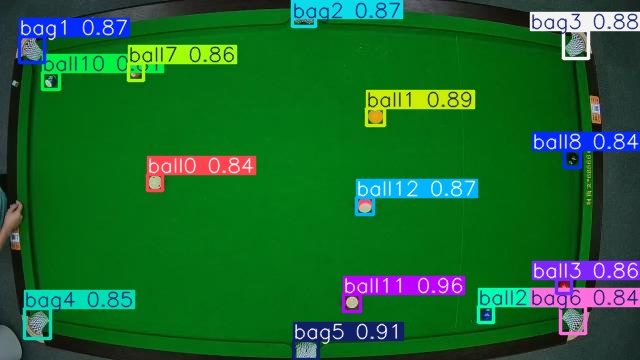

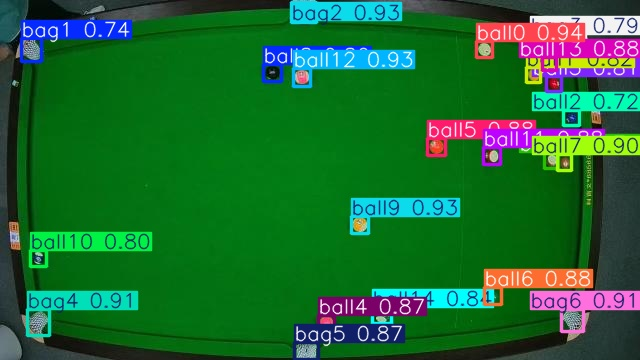

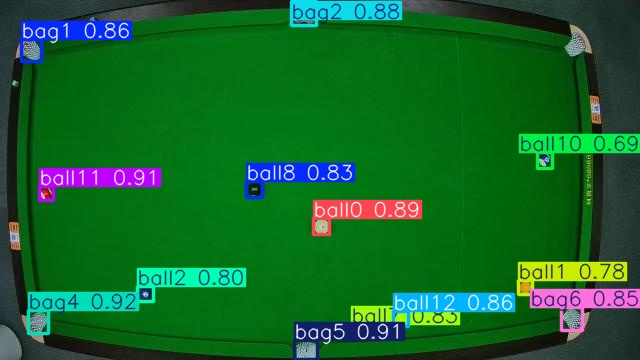

In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")